In [1]:
import pickle

with open("extra/datasets/annotations/mm9/refGene.all_transcripts.ensm2TSS.pkl", "rb") as f:
    ensm2TSS = pickle.load(f)



In [2]:
ensm2TSS['ENSMUSG00000000730']

[('chr10', 77505031, 77505032, '+'),
 ('chr10', 77512703, 77512704, '+'),
 ('chr10', 77518079, 77518080, '+'),
 ('chr10', 77518079, 77518080, '+'),
 ('chr10', 77518079, 77518080, '+'),
 ('chr10', 77512586, 77512587, '+')]

# Load H1 Model 

In [3]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path

from src.model.net import DeepBurst
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config

from benchmarks.revised_v2.reviewer1.data_extractor import HistoneExtractor


# ============================================================
# 1. Basic configuration
# ============================================================

eid = "E003"
# gene_id = "ENSG00000117602"


ensg2tss_path="extra/datasets/annotations/mm9/refGene.all_transcripts.ensm2TSS.pkl",
bigwig_dir="extra/datasets/epigenetic/mm9",
meta_dir = Path("extra/datasets/processed/v2/meta_datasets")

config_path = "configs/default.yaml"
config = get_config(config_path)

seed = 42
seed_everything(seed)

remove_marks = None
if remove_marks:
    config["remove_marks"] = [remove_marks] if isinstance(remove_marks, str) else list(remove_marks)
else:
    config["remove_marks"] = []

config["marked_bin_idxes"] = []
config["masked_marks"] = []

n_feats_p = config["promoter_feats_basic_nums"] - len(config["remove_marks"])
d_emb = config["embed"]["d_model"]
d_head = config["d_head"]
embed_kws = config["embed"]

targets = ["bs_label", "bf_label"]
binsizes = [500]
bin_size = 500

strand_oriented = True

eid2celltype = {
    "E003": "H1",
    "E116": "GM12878",
    "E118": "HepG2",
}

celltype = eid2celltype.get(eid, eid)

print("eid:", eid)
print("celltype:", celltype)
# print("gene_id:", gene_id)
print("DEVICE:", DEVICE)

/Users/wanghan/miniconda3/envs/deepburst/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


eid: E003
celltype: H1
DEVICE: cpu


In [4]:
# ============================================================
# 2. Chromosome split logic
# Must match the training code
# ============================================================

def build_chromosome_splits():
    splits = {
        1: ["chr1", "chr6", "chr5", "chr8", "chr14", "chrY"],
        2: ["chr7", "chr10", "chr11", "chr12", "chr15", "chr21"],
        3: ["chr2", "chr3", "chr4", "chr16", "chr18", "chr20"],
        4: ["chr9", "chr13", "chr17", "chr19", "chr22", "chrX"],
    }

    chromosome_splits = {}
    for split_id, chroms in splits.items():
        for chrom in chroms:
            chromosome_splits[chrom] = split_id

    return chromosome_splits


CHROMOSOME_SPLITS = build_chromosome_splits()


def chrom_to_fold(chrom):
    """
    Match training code:

        val_genes = qs[(fold + 3) % 4]

    Therefore:
        fold 0 -> split 4
        fold 1 -> split 1
        fold 2 -> split 2
        fold 3 -> split 3

    So:
        split_id -> fold = split_id % 4
    """
    chrom = str(chrom)

    if chrom not in CHROMOSOME_SPLITS:
        raise ValueError(f"Unknown chromosome: {chrom}")

    split_id = CHROMOSOME_SPLITS[chrom]
    return split_id % 4

In [5]:
# ============================================================
# 3. Model loading
# ============================================================

def get_checkpoint_path(eid, fold, config, remove_marks=None):
    if remove_marks:
        remove_name = "_".join(config["remove_marks"])
        ckpt_path = f"checkpoints/{eid}.remove_{remove_name}.{fold}.bs_bf_para.model.pt"
    else:
        ckpt_path = f"checkpoints/{eid}.{fold}.bs_bf_para.model.pt"

    return ckpt_path


def build_deepburst_model():
    model = DeepBurst(
        n_feats_p,
        d_emb,
        d_head,
        embed_kws=embed_kws,
        binsizes=binsizes,
        seed=42,
        targets=targets,
    ).to(DEVICE)

    return model


def load_deepburst_model(eid, fold, config, remove_marks=None):
    model = build_deepburst_model()

    ckpt_path = get_checkpoint_path(
        eid=eid,
        fold=fold,
        config=config,
        remove_marks=remove_marks,
    )

    if not Path(ckpt_path).exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["net"])
    model.eval()

    return model, ckpt_path


def load_all_fold_models(eid, config, remove_marks=None, folds=(0, 1, 2, 3)):
    model_dict = {}

    for fold in folds:
        print(f"[Load model] eid={eid}, fold={fold}")

        model, ckpt_path = load_deepburst_model(
            eid=eid,
            fold=fold,
            config=config,
            remove_marks=remove_marks,
        )

        model_dict[int(fold)] = {
            "model": model,
            "checkpoint": ckpt_path,
        }

    return model_dict

In [6]:
# ============================================================
# 4. Tensor helpers
# ============================================================

def move_to_device(obj, device):
    if torch.is_tensor(obj):
        return obj.to(device)

    if isinstance(obj, dict):
        return {k: move_to_device(v, device) for k, v in obj.items()}

    if isinstance(obj, list):
        return [move_to_device(v, device) for v in obj]

    if isinstance(obj, tuple):
        return tuple(move_to_device(v, device) for v in obj)

    return obj

def make_model_inputs_from_X(X, bin_size=500):
    """
    Convert extracted histone matrix to DeepBurst input.

    X:
        np.ndarray, shape = (B, 80, 7)

    Return:
        model_inputs["promoter_feats"][500]:
            torch.Tensor, shape = (B, 1, 80, 7)
    """
    if not isinstance(X, np.ndarray):
        X = np.asarray(X)

    X_tensor = torch.from_numpy(X).float()

    if X_tensor.ndim != 3:
        raise ValueError(
            f"Expected X shape = (B, n_bins, n_marks), got {X_tensor.shape}"
        )

    model_inputs = {
        "promoter_feats": {
            bin_size: X_tensor.unsqueeze(1)
        }
    }

    return model_inputs


def parse_deepburst_output(out, targets=("bs_label", "bf_label")):
    """
    Follow validation logic:

        torch.chunk(out, len(targets), axis=-1)

    Each target has two logits.

    Output:
        bs_label_score, bs_label_pred,
        bf_label_score, bf_label_pred
    """
    pred_chunks = torch.chunk(out, len(targets), dim=-1)

    records = {}

    for target, logits in zip(targets, pred_chunks):
        score = logits.softmax(dim=1)[:, 1]
        pred = logits.argmax(dim=1)

        records[f"{target}_score"] = score.detach().cpu().numpy()
        records[f"{target}_pred"] = pred.detach().cpu().numpy()

    return pd.DataFrame(records)

## Load data extractor

In [7]:
# ============================================================
# 5. Initialize extractor
# ============================================================

extractor = HistoneExtractor(
    ensg2tss_path="extra/datasets/annotations/mm9/refGene.all_transcripts.ensm2TSS.pkl",
    bigwig_dir="extra/datasets/epigenetic/mm9",
    eid="ES-Bruce4",
    seed=20240531,
    log1p=True,
)

## Load models

In [8]:
# ============================================================
# 9. Load all fold models
# ============================================================

model_dict = load_all_fold_models(
    eid=eid,
    config=config,
    remove_marks=remove_marks,
    folds=(0, 1, 2, 3),
)

[Load model] eid=E003, fold=0
[Load model] eid=E003, fold=1
[Load model] eid=E003, fold=2
[Load model] eid=E003, fold=3


In [9]:
def predict_all_tss_for_gene(
    extractor,
    model_dict,
    eid,
    gene_id,
    unique=True,
    strand_oriented=True,
    bin_size=500,
    return_X=False,
):
    """
    Predict BF/BS scores for all annotated TSSs of one gene.

    Returns
    -------
    pred_all_tss_df:
        One row per TSS.

    X_all:
        Returned only when return_X=True.
        Shape = (n_tss, n_bins, n_marks).
    """
    # celltype = eid2celltype.get(eid, eid)

    # ------------------------------------------------------------
    # 1. Get all TSSs
    # ------------------------------------------------------------
    tss_df = extractor.get_all_tss(
        gene_id,
        unique=unique,
        as_dataframe=True,
    ).reset_index(drop=True)

    if tss_df.empty:
        raise ValueError(f"No TSS found for gene_id={gene_id}")

    # ------------------------------------------------------------
    # 2. Extract matrix for each TSS
    # ------------------------------------------------------------
    X_list = []
    meta_list = []

    for _, row in tss_df.iterrows():
        X_tss, tss_meta = extractor.get_tss_matrix(
            tss=row,
            strand_oriented=strand_oriented,
            add_batch_dim=False,
            return_meta=True,
        )

        X_list.append(X_tss)
        meta_list.append(tss_meta)

    X_all = np.stack(X_list, axis=0).astype(np.float32)
    meta_df = pd.DataFrame(meta_list).reset_index(drop=True)

    # ------------------------------------------------------------
    # 3. Assign fold
    # ------------------------------------------------------------
    meta_df["fold"] = meta_df["chrom"].apply(chrom_to_fold).astype(int)

    # ------------------------------------------------------------
    # 4. Convert to DeepBurst input
    # X_all: (n_tss, 80, 7)
    # fold_x_all: (n_tss, 1, 80, 7)
    # ------------------------------------------------------------
    X_tensor = torch.from_numpy(X_all).float()
    fold_x_all = X_tensor.unsqueeze(1)

    # ------------------------------------------------------------
    # 5. Predict by fold
    # ------------------------------------------------------------
    all_pred_parts = []

    for fold, sub_meta in meta_df.groupby("fold", sort=False):
        fold = int(fold)

        if fold not in model_dict:
            raise KeyError(f"Fold {fold} not found in model_dict")

        model = model_dict[fold]["model"]
        ckpt_path = model_dict[fold]["checkpoint"]

        idx = torch.tensor(sub_meta.index.to_numpy(), dtype=torch.long)

        fold_x = fold_x_all[idx].to(DEVICE)

        model.eval()
        with torch.no_grad():
            out = model(fold_x)

        pred_part = parse_deepburst_output(
            out,
            targets=targets,
        )

        result_part = sub_meta.reset_index(drop=True).copy()
        result_part = pd.concat([result_part, pred_part], axis=1)

        result_part["eid"] = eid
        # result_part["celltype"] = celltype
        result_part["checkpoint"] = ckpt_path

        all_pred_parts.append(result_part)

    pred_all_tss_df = (
        pd.concat(all_pred_parts, axis=0)
        .sort_values(["tss_index", "chrom", "start"])
        .reset_index(drop=True)
    )

    # ------------------------------------------------------------
    # 6. Reorder columns
    # ------------------------------------------------------------
    preferred_cols = [
        "eid",
        # "celltype",
        "gene_id",
        "tss_index",
        "chrom",
        "start",
        "end",
        "strand",
        "tss",
        "is_first_tss",
        "distance_to_first_tss_bp",
        "n_tss_raw",
        "n_tss_unique",
        "fold",
        "bs_label_score",
        "bs_label_pred",
        "bf_label_score",
        "bf_label_pred",
        "checkpoint",
    ]

    existing_cols = [c for c in preferred_cols if c in pred_all_tss_df.columns]
    other_cols = [c for c in pred_all_tss_df.columns if c not in existing_cols]

    pred_all_tss_df = pred_all_tss_df[existing_cols + other_cols]

    if return_X:
        return pred_all_tss_df, X_all

    return pred_all_tss_df

In [14]:
gene_names = [
    "Birc6", "Cdt1", "Ctcf", "Ddx42", "Dhx15", "Dnmt3b", "Dnmt3l",
    "Eif4a1", "Etv5", "Gsk3b", "Hdac1", "Hes1", "Kdm1a",
    "Klf4", "Nanog", "Ncapd3", "Npm1", "Peg3", "Rad21", "Rif1",
    "Slc2a3", "Ssrp1", "Trim27", "Trim28",
    "Pou5f1",'Sox2',
]


def get_gene_ids_by_names(annotation, gene_names, sep="\t"):
    if isinstance(annotation, str):
        df = pd.read_csv(annotation, sep=sep)
    else:
        df = annotation.copy()

    gene_names = [str(x) for x in gene_names]

    out = (
        df[df["gene_name"].isin(gene_names)]
        [["gene_name", "gene_id"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    gene_id_list = out["gene_id"].tolist()
    return gene_id_list, out


gene_ids, matched_df = get_gene_ids_by_names(

    annotation="extra/datasets/annotations/mm9/refGene.all_transcripts.ensm2TSS.tsv",

    gene_names=gene_names,

)

print(gene_ids)

matched_df

['ENSMUSG00000024073', 'ENSMUSG00000006585', 'ENSMUSG00000005698', 'ENSMUSG00000020705', 'ENSMUSG00000029169', 'ENSMUSG00000027478', 'ENSMUSG00000000730', 'ENSMUSG00000059796', 'ENSMUSG00000013089', 'ENSMUSG00000022812', 'ENSMUSG00000028800', 'ENSMUSG00000022528', 'ENSMUSG00000036940', 'ENSMUSG00000003032', 'ENSMUSG00000012396', 'ENSMUSG00000035024', 'ENSMUSG00000057113', 'ENSMUSG00000002265', 'ENSMUSG00000024406', 'ENSMUSG00000022314', 'ENSMUSG00000036202', 'ENSMUSG00000003153', 'ENSMUSG00000074637', 'ENSMUSG00000027067', 'ENSMUSG00000021326', 'ENSMUSG00000005566']


,gene_name,gene_id
0,Birc6,ENSMUSG00000024073
1,Cdt1,ENSMUSG00000006585
2,Ctcf,ENSMUSG00000005698
3,Ddx42,ENSMUSG00000020705
4,Dhx15,ENSMUSG00000029169
5,Dnmt3b,ENSMUSG00000027478
6,Dnmt3l,ENSMUSG00000000730
7,Eif4a1,ENSMUSG00000059796
8,Etv5,ENSMUSG00000013089
9,Gsk3b,ENSMUSG00000022812


In [15]:
# ============================================================
# Predict all TSSs of one gene
# ============================================================
# ENSMUSG00000000730	Dnmt3l
# gene_names = ["Hdac6", "Msl3", "Mpp1", "Igbp1",'Nanog',"Dnmt3l"]
# gene_ids = ["ENSMUSG00000031161", "ENSMUSG00000031358","ENSMUSG00000031402","ENSMUSG00000031221","ENSMUSG00000012396","ENSMUSG00000000730"]
results = pd.DataFrame()
for gene_name, gene_id in matched_df.itertuples(index=False):
    pred_all_tss_df = predict_all_tss_for_gene(
        extractor=extractor,
        model_dict=model_dict,
        eid=eid,
        gene_id=gene_id,
        unique=True,
        strand_oriented=True,
        bin_size=500,
        return_X=False,
    )
    pred_all_tss_df['gene_name'] = gene_name
    results = pd.concat([results, pred_all_tss_df[['gene_id','gene_name', 'tss_index', 'chrom', 'start', 'end','strand', 'bs_label_score','bs_label_pred','bf_label_score','bf_label_pred']]], ignore_index=True)

results

,gene_id,gene_name,tss_index,chrom,start,end,strand,bs_label_score,bs_label_pred,bf_label_score,bf_label_pred
0,ENSMUSG00000024073,Birc6,0,chr17,74927634,74927635,+,0.669975,1,0.886304,1
1,ENSMUSG00000006585,Cdt1,0,chr8,125091914,125091915,+,0.685282,1,0.988595,1
2,ENSMUSG00000005698,Ctcf,0,chr8,108160437,108160438,+,0.629566,1,0.636799,1
3,ENSMUSG00000020705,Ddx42,0,chr11,106091979,106091980,+,0.193598,0,0.097876,0
4,ENSMUSG00000020705,Ddx42,1,chr11,106078239,106078240,+,0.719056,1,0.710776,1
5,ENSMUSG00000029169,Dhx15,0,chr5,52581784,52581785,-,0.734038,1,0.946846,1
6,ENSMUSG00000027478,Dnmt3b,0,chr2,153475184,153475185,+,0.691887,1,0.885867,1
7,ENSMUSG00000000730,Dnmt3l,0,chr10,77505031,77505032,+,0.378457,0,0.253422,0
8,ENSMUSG00000000730,Dnmt3l,1,chr10,77512703,77512704,+,0.625737,1,0.829214,1
9,ENSMUSG00000000730,Dnmt3l,2,chr10,77518079,77518080,+,0.373649,0,0.248984,0


In [17]:
# ============================================================
# Predict all TSSs of one gene
# ============================================================
# ENSMUSG00000000730	Dnmt3l
gene_names = ["Msl3",'Nanog','Sox2']
# gene_ids = ["ENSMUSG00000031161", "ENSMUSG00000031358","ENSMUSG00000031402","ENSMUSG00000031221","ENSMUSG00000012396","ENSMUSG00000000730"]


gene_ids, matched_df = get_gene_ids_by_names(
                    annotation="extra/datasets/annotations/mm9/refGene.all_transcripts.ensm2TSS.tsv",
                    gene_names=gene_names,
                    )
results = pd.DataFrame()
for gene_name, gene_id in matched_df.itertuples(index=False):
    pred_all_tss_df = predict_all_tss_for_gene(
        extractor=extractor,
        model_dict=model_dict,
        eid=eid,
        gene_id=gene_id,
        unique=True,
        strand_oriented=True,
        bin_size=500,
        return_X=False,
    )
    pred_all_tss_df['gene_name'] = gene_name
    results = pd.concat([results, pred_all_tss_df[['gene_id','gene_name', 'tss_index', 'chrom', 'start', 'end','strand', 'bs_label_score','bs_label_pred','bf_label_score','bf_label_pred']]], ignore_index=True)

results

,gene_id,gene_name,tss_index,chrom,start,end,strand,bs_label_score,bs_label_pred,bf_label_score,bf_label_pred
0,ENSMUSG00000031358,Msl3,0,chrX,165111803,165111804,-,0.542084,1,0.357249,0
1,ENSMUSG00000031358,Msl3,1,chrX,165110956,165110957,-,0.607818,1,0.654270,1
2,ENSMUSG00000012396,Nanog,0,chr6,122657582,122657583,+,0.723369,1,0.885005,1
3,ENSMUSG00000012396,Nanog,1,chr6,122657506,122657507,+,0.727736,1,0.927970,1
4,ENSMUSG00000074637,Sox2,0,chr3,34548916,34548917,+,0.611540,1,0.822369,1


## case summary

In [ ]:


# ------------------------------------------------------------
# 1. Convert wide table to long format
# ------------------------------------------------------------

plot_df = pred_all_tss_df.copy()

score_long_df = plot_df.melt(
    id_vars=[
        "gene_id",
        "tss_index",
        "chrom",
        "start",
        "end",
        "strand",
    ],
    value_vars=[
        "bf_label_score",
        "bs_label_score",
    ],
    var_name="target",
    value_name="score",
)

score_long_df["target"] = score_long_df["target"].map({
    "bf_label_score": "BF",
    "bs_label_score": "BS",
})

score_long_df["target"] = pd.Categorical(
    score_long_df["target"],
    categories=["BF", "BS"],
    ordered=True,
)

score_long_df.head()

,gene_id,tss_index,chrom,start,end,strand,target,score
0,ENSG00000196628,0,chr18,53255423,53255424,-,BF,0.970940
1,ENSG00000196628,1,chr18,53303188,53303189,-,BF,0.055659
2,ENSG00000196628,2,chr18,53257042,53257043,-,BF,0.963219
3,ENSG00000196628,3,chr18,53255860,53255861,-,BF,0.988708
4,ENSG00000196628,4,chr18,53178003,53178004,-,BF,0.513574


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_97319/3719061301.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


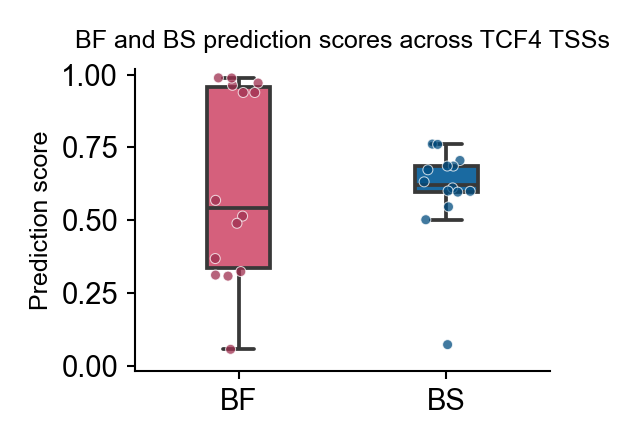

In [ ]:
fig, ax = plt.subplots(figsize=(5 / 2.54, 4 / 2.54))

box_palette = {
    "BF": "#E94C72",
    "BS": "#036EB8",
}

point_palette = {
    "BF": "#9E2F4F",   # darker rose
    "BS": "#014C7F",   # darker blue
}

sns.boxplot(
    data=score_long_df,
    x="target",
    y="score",
    order=["BF", "BS"],
    width=0.3,
    showfliers=False,
    ax=ax,
    palette=box_palette,
    linewidth=0.9,
)

sns.stripplot(
    data=score_long_df,
    x="target",
    y="score",
    order=["BF", "BS"],
    hue="target",
    palette=point_palette,
    size=2.4,
    jitter=0.12,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.25,
    ax=ax,
    legend=False,
)

ax.set_xlabel("")
ax.set_ylabel("Prediction score")
ax.set_ylim(-0.02, 1.02)

ax.set_title(
    "BF and BS prediction scores across TCF4 TSSs",
    pad=5,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", labelsize=7)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()

out_path = f"benchmarks/revised_v2/reviewer1/figures/TCF4_prediction_scores.pdf"
plt.savefig(out_path, format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
tss_df = extractor.get_all_tss(
    gene_id,
    unique=True,
    as_dataframe=True,
)

tss_df

,gene_id,tss_index,chrom,start,end,strand,tss,is_first_tss,first_chrom,first_start,first_end,first_strand,first_tss,distance_to_first_tss_bp,n_tss_raw,n_tss_unique,is_unique_output
0,ENSG00000196628,0,chr18,53255423,53255424,-,53255423,True,chr18,53255423,53255424,-,53255423,0,46,14,True
1,ENSG00000196628,1,chr18,53303188,53303189,-,53303188,False,chr18,53255423,53255424,-,53255423,47765,46,14,True
2,ENSG00000196628,2,chr18,53257042,53257043,-,53257042,False,chr18,53255423,53255424,-,53255423,1619,46,14,True
3,ENSG00000196628,3,chr18,53255860,53255861,-,53255860,False,chr18,53255423,53255424,-,53255423,437,46,14,True
4,ENSG00000196628,4,chr18,53178003,53178004,-,53178003,False,chr18,53255423,53255424,-,53255423,77420,46,14,True
5,ENSG00000196628,5,chr18,53071226,53071227,-,53071226,False,chr18,53255423,53255424,-,53255423,184197,46,14,True
6,ENSG00000196628,6,chr18,53089528,53089529,-,53089528,False,chr18,53255423,53255424,-,53255423,165895,46,14,True
7,ENSG00000196628,7,chr18,52989072,52989073,-,52989072,False,chr18,53255423,53255424,-,53255423,266351,46,14,True
8,ENSG00000196628,8,chr18,52969891,52969892,-,52969891,False,chr18,53255423,53255424,-,53255423,285532,46,14,True
9,ENSG00000196628,9,chr18,53253350,53253351,-,53253350,False,chr18,53255423,53255424,-,53255423,2073,46,14,True


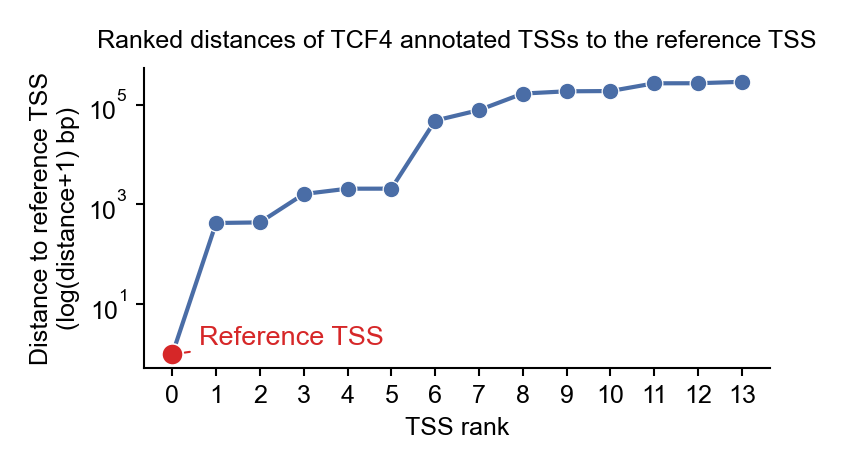

In [ ]:
# ------------------------------------------------------------
# Log-scale version: sorted by distance
# ------------------------------------------------------------

plot_df = tss_df.copy()

plot_df["tss_index"] = plot_df["tss_index"].astype(int)
plot_df["distance_to_first_tss_bp"] = plot_df["distance_to_first_tss_bp"].astype(float)
plot_df["distance_plus1"] = plot_df["distance_to_first_tss_bp"] + 1

# 按距离从小到大排序；距离相同再按原始 tss_index 排序
plot_df = (
    plot_df
    .sort_values(["distance_to_first_tss_bp", "tss_index"])
    .reset_index(drop=True)
)

# 排序后的横坐标
plot_df["ranked_tss_index"] = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(7.0 / 2.54, 4.2 / 2.54))

# ------------------------------------------------------------
# Main line
# ------------------------------------------------------------

ax.plot(
    plot_df["ranked_tss_index"],
    plot_df["distance_plus1"],
    marker="o",
    markersize=4,
    linewidth=1.0,
    color="#4A6DA6",
    markerfacecolor="#4A6DA6",
    markeredgecolor="white",
    markeredgewidth=0.3,
    zorder=2,
)

# ------------------------------------------------------------
# Highlight reference TSS
# ------------------------------------------------------------

ref_row = plot_df.iloc[0]

ax.scatter(
    ref_row["ranked_tss_index"],
    ref_row["distance_plus1"],
    s=26,
    color="#D62728",
    edgecolor="white",
    linewidth=0.4,
    zorder=4,
)

ax.annotate(
    "Reference TSS",
    xy=(ref_row["ranked_tss_index"], ref_row["distance_plus1"]),
    xytext=(ref_row["ranked_tss_index"] + 0.6, ref_row["distance_plus1"] * 2.2),
    fontsize=6.5,
    color="#D62728",
    ha="left",
    va="center",
    arrowprops={
        "arrowstyle": "-",
        "lw": 0.5,
        "color": "#D62728",
        "shrinkA": 0,
        "shrinkB": 3,
    },
)

# ------------------------------------------------------------
# Axis style
# ------------------------------------------------------------

ax.set_yscale("log")

ax.set_xlabel("TSS rank")
ax.set_ylabel("Distance to reference TSS\n(log(distance+1) bp)")

ax.set_title(
    "Ranked distances of TCF4 annotated TSSs to the reference TSS",
    pad=5,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", )
ax.tick_params(axis="y", )

ax.set_xticks(plot_df["ranked_tss_index"].to_numpy())

plt.tight_layout()
out_path = f"benchmarks/revised_v2/reviewer1/figures/TCF4_TSSs_distance_ranking.pdf"
plt.savefig(out_path, format="pdf", bbox_inches="tight")
plt.show()